#### Single-mode coupled mode theory — Laís thesis Eq. (4.5)

Solves:
    $$ \frac{da_0}{d\tau} = -(1 + iΔ₀) a₀  -  i|a₀|² a₀  +  s $$

Variables (all dimensionless, normalized to κ/2):
- $\tau$      = (κ/2) t             — normalized time
- a₀     = √(2g₀/κ) A₀        — normalized intracavity amplitude
- Δ₀     = (2/κ)(ωp - ω₀)     — normalized detuning (positive = blue)
- s      = √(8η g₀/κ³) S_in   — normalized drive amplitude
- |s|²   = 2η P_in / P_th     — so s=1 means P_in = P_th/2η ≈ P_th

We scan Δ₀ slowly across the resonance (from blue to red, i.e. Δ → -Δ)
to simulate the experimental laser-frequency sweep.

Physical interpretation of each term:
- -(1)·a₀        : cavity decay (loss rate = κ/2, normalized to 1)
- -iΔ₀·a₀        : detuning — field rotates at residual frequency Δ₀
- -i|a₀|²·a₀     : Kerr SPM — intensity shifts resonance (g absorbed into a)
- +s              : coherent pump drive


In [1]:
using DifferentialEquations
using Plots
using Polynomials

# Use a clean plot theme similar to seaborn
default(framestyle=:box, grid=true, gridalpha=0.3)

##### Equation of motion


In [ ]:
"""
Right-hand side of the single-mode CMT equation.

u : [Re(a), Im(a)]  — split into real parts for the ODE solver
p : (Delta, s)      — normalized detuning and drive amplitude
t : time (τ)
"""

function da_dt!(du, u, p, t)
    Delta, s = p
    a = u[1] + im * u[2]          # reconstruct complex amplitude

    dadt = -(1 + im * Delta) * a  -  im * abs2(a) * a  +  s

    du[1] = real(dadt)
    du[2] = imag(dadt)
end

da_dt!

##### Detuning sweep


In [3]:
"""
Slowly scan Δ₀ across the resonance, letting the field settle at each step.

At each detuning step, we:
  1. Integrate the ODE for tau_settle time units (field settles to steady state)
  2. Record |a|² and |s - a|² (transmission) at the end

Returns:
    Deltas   : array of detuning values
    n_intra  : intracavity photon number |a|²
    T        : transmission |s - a|²
"""
function sweep(s, delta_range; n_points=2000, tau_settle=30.0)
    Deltas  = range(delta_range[1], delta_range[2], length=n_points)
    n_intra = zeros(n_points)
    T       = zeros(n_points)

    # Start with a = 0 (empty cavity)
    state = [0.0, 0.0]

    for (k, Delta) in enumerate(Deltas)
        prob = ODEProblem(da_dt!, state, (0.0, tau_settle), (Delta, s))
        sol  = solve(prob, RK4();
                     reltol=1e-8, abstol=1e-10,
                     dense=false, save_everystep=false)

        state = sol.u[end]               # use final state as IC for next step

        a = state[1] + im * state[2]
        n_intra[k] = abs2(a)
        T[k]       = abs2(s - a)         # output field = input - coupled-out field
    end

    return collect(Deltas), n_intra, T
end

sweep

In [7]:
# Drive amplitudes: s=1 → P ≈ P_th;  s=√3 → P ≈ 3P_th (threshold for bistability)
# Bistability requires s² > 4/(3√3) ≈ 0.77, i.e. s > 0.88
drive_values = [0.5, 1.0, 1.5, 2.0]   # normalized drive amplitudes


4-element Vector{Float64}:
 0.5
 1.0
 1.5
 2.0

In [5]:
# Scan blue-to-red (positive to negative detuning)
delta_range_fwd = ( 5.0, -5.0)   # forward scan (blue→red)
delta_range_bwd = (-5.0,  5.0)   # backward scan (red→blue), shows hysteresis

(-5.0, 5.0)

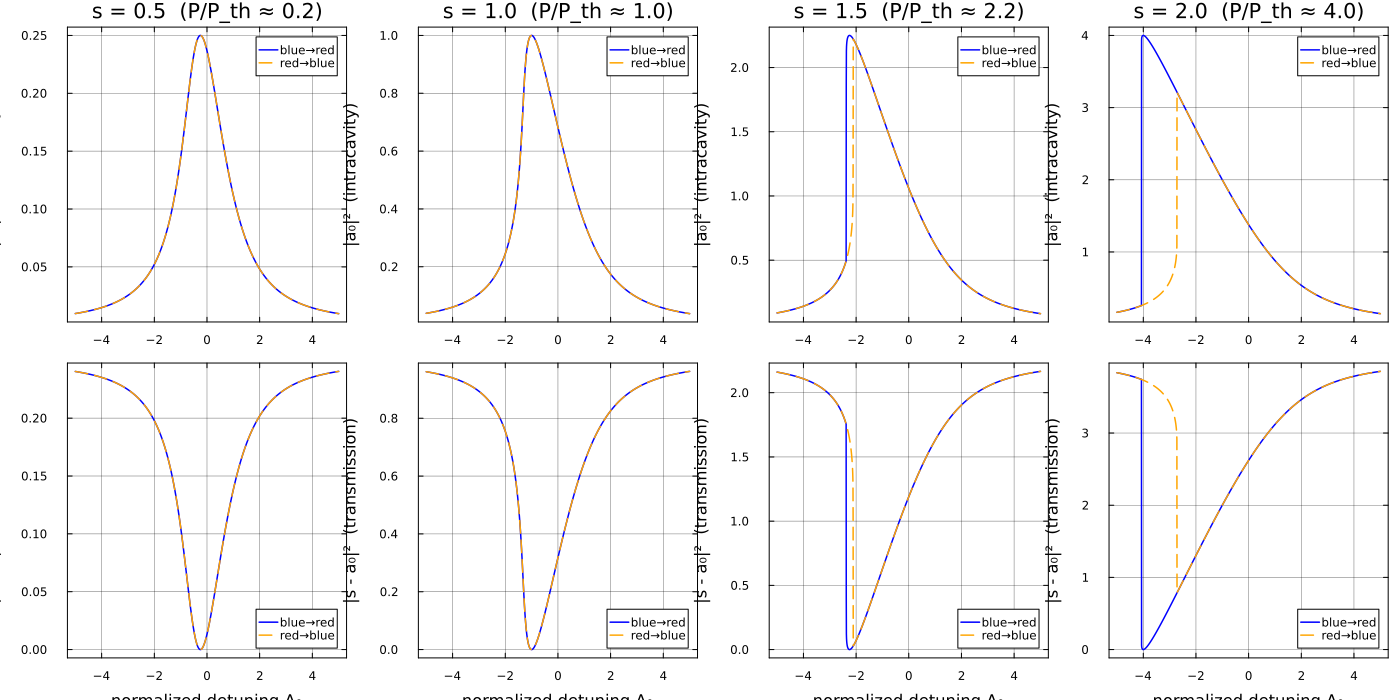

In [8]:
fig = plot(layout=(2, length(drive_values)), size=(1400, 700))

for (ind, s) in enumerate(drive_values)
    D_fwd, n_fwd, T_fwd = sweep(s, delta_range_fwd)
    D_bwd, n_bwd, T_bwd = sweep(s, delta_range_bwd)

    # Row 1: Intracavity power
    plot!(fig[1, ind],
        D_fwd, n_fwd,
        color=:blue, lw=1.5, label="blue→red",
        title="s = $s  (P/P_th ≈ $(round(s^2, digits=1)))",
        ylabel="|a₀|²  (intracavity)",
        xlabel=""
    )
    plot!(fig[1, ind],
        D_bwd, n_bwd,
        color=:orange, lw=1.5, ls=:dash, label="red→blue"
    )

    # Row 2: Transmission
    plot!(fig[2, ind],
        D_fwd, T_fwd,
        color=:blue, lw=1.5, label="blue→red",
        ylabel="|s - a₀|²  (transmission)",
        xlabel="normalized detuning Δ₀"
    )
    plot!(fig[2, ind],
        D_bwd, T_bwd,
        color=:orange, lw=1.5, ls=:dash, label="red→blue"
    )
end

display(fig)
# savefig(fig, "01_SM_Bistability.pdf")

#### Steady-state analytic check
At steady state da/dt = 0, so:

$\vert a\vert ^2 * [(1)^2 + (\Delta - \vert a\vert ^2)^2]  = s^2$

We solve this numerically and overlay on the simulation to verify.


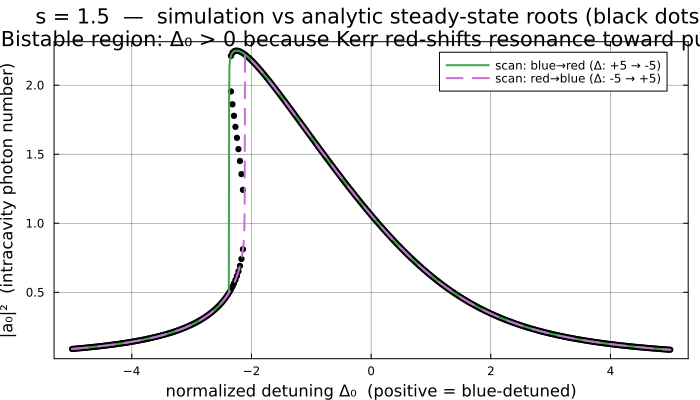

In [10]:
s_check = 1.5
Deltas_check = range(-5, 5, length=400)

# For each Δ, solve cubic: n³ + 2Δn² + (1+Δ²)n - s² = 0,  where n = |a|²
n_analytic = [Float64[] for _ in Deltas_check]

for (k, D) in enumerate(Deltas_check)
    # Polynomial coefficients (highest power first for Polynomials.jl: use `roots`)
    # n^3 + 2D*n^2 + (1+D^2)*n - s^2 = 0
    p = Polynomial([-s_check^2, 1 + D^2, 2*D, 1.0])  # lowest to highest power
    rts = roots(p)
    real_positive = [real(r) for r in rts if abs(imag(r)) < 1e-9 && real(r) >= 0]
    n_analytic[k] = real_positive
end

fig2 = plot(size=(700, 400),
    xlabel="normalized detuning Δ₀  (positive = blue-detuned)",
    ylabel="|a₀|²  (intracavity photon number)",
    title="s = $s_check  —  simulation vs analytic steady-state roots (black dots)\n" *
          "Bistable region: Δ₀ > 0 because Kerr red-shifts resonance toward pump"
)

# Analytic roots — scatter all real positive roots
for (k, D) in enumerate(Deltas_check)
    for n_val in n_analytic[k]
        scatter!(fig2, [D], [n_val], color=:black, ms=3.5, label=false)
    end
end

D_fwd, n_fwd, _ = sweep(s_check, (5.0, -5.0))   # blue→red: starts high-Δ
plot!(fig2, D_fwd, n_fwd, lw=2, label="scan: blue→red (Δ: +5 → -5)")

D_bwd, n_bwd, _ = sweep(s_check, (-5.0, 5.0))   # red→blue: starts low-Δ
plot!(fig2, D_bwd, n_bwd, lw=2, ls=:dash, label="scan: red→blue (Δ: -5 → +5)")

display(fig2)
# savefig(fig2, "01_SM_Analytic_solution_comparison.pdf")